# CIMA PCA 整理版

这个版本把原来的流程收成几步：

1. VCF 转 pgen  
2. 样本名统一成 `BGE编号`  
3. 和 meta 做交集  
4. PCA 前过滤 + LD pruning  
5. 跑 PCA  
6. 把 PCA 合并回 meta，并整理一个画图表

小结果统一存成 `csv / tsv / txt`，不存 parquet。

In [16]:
from pathlib import Path
import pandas as pd
import numpy as np

# ===== 路径设置（相对项目根目录）=====
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and PROJECT_ROOT.name != "CIMA_multiomics_regulation":
    PROJECT_ROOT = PROJECT_ROOT.parent

if PROJECT_ROOT.name != "CIMA_multiomics_regulation":
    raise RuntimeError("未找到项目根目录 CIMA_multiomics_regulation，请在项目目录内运行该脚本。")

ROOT = PROJECT_ROOT
RAW_VCF = ROOT / "data/raw/CIMA/Gene/CIMA_phasing.merged"
META_CSV = ROOT / "data/processed/CIMA/meta_inventory/basic_id_sex_age.csv"

GENO_DIR = ROOT / "data/processed/genotype"
INTER_DIR = ROOT / "data/processed/sample_intersection"
META_DIR = ROOT / "data/processed/meta"
QC_DIR = META_DIR / "origin_qc"

GENO_DIR.mkdir(parents=True, exist_ok=True)
INTER_DIR.mkdir(parents=True, exist_ok=True)
QC_DIR.mkdir(parents=True, exist_ok=True)

print(ROOT)
print(RAW_VCF)
print(META_CSV)

/data/work/CIMA_multiomics_regulation
/data/work/CIMA_multiomics_regulation/data/raw/CIMA/Gene/CIMA_phasing.merged
/data/work/CIMA_multiomics_regulation/data/processed/CIMA/meta_inventory/basic_id_sex_age.csv


## 1. 转 pgen，并生成重命名表

这里统一把原始样本名：

`E-B21106356138-4_E-B21106356138-4`

改成：

`E-B21106356138`

同时会检查新 ID 是否重复。

In [17]:
!bcftools query -l {RAW_VCF} > {GENO_DIR / 'genotype_samples.txt'}

!plink2 \
  --vcf {RAW_VCF} \
  --make-pgen \
  --out {GENO_DIR / 'CIMA_raw'}

psam = pd.read_csv(GENO_DIR / "CIMA_raw.psam", sep=r"\s+")

if "#IID" in psam.columns:
    iid_col = "#IID"
elif "IID" in psam.columns:
    iid_col = "IID"
else:
    raise ValueError(f"没找到 IID 列: {psam.columns.tolist()}")

if "#FID" in psam.columns:
    fid_col = "#FID"
elif "FID" in psam.columns:
    fid_col = "FID"
else:
    fid_col = None

iid = psam[iid_col].astype(str).str.strip()
fid = psam[fid_col].astype(str).str.strip() if fid_col else pd.Series(["0"] * len(psam), index=psam.index)

new_id = (
    iid.str.split("_").str[0]
       .str.replace(r"-4$", "", regex=True)
       .str.strip()
)

update = pd.DataFrame({
    "oldFID": fid,
    "oldIID": iid,
    "newFID": new_id,
    "newIID": new_id,
})

dup = update[update["newIID"].duplicated(keep=False)].copy()
if not dup.empty:
    raise ValueError("newIID 出现重复，先不要继续 update-ids。")

update.to_csv(GENO_DIR / "update_ids.tsv", sep="\t", index=False, header=False)
update[["oldIID", "newIID"]].to_csv(GENO_DIR / "update_ids_check.csv", index=False)

display(update.head())
print("n =", len(update))

bcftools: error while loading shared libraries: libcrypto.so.1.0.0: cannot open shared object file: No such file or directory
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw.log.
Options in effect:
  --make-pgen
  --out /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw
  --vcf /data/work/CIMA_multiomics_regulation/data/raw/CIMA/Gene/CIMA_phasing.merged

Start time: Thu Apr 16 14:45:53 2026
2051949 MiB RAM detected, ~356809 available; reserving 356745 MiB for main
workspace.
Using up to 256 threads (change this with --threads).
Error: Failed to open
/data/work/CIMA_multiomics_regulation/data/raw/CIMA/Gene/CIMA_phasing.merged :
No such file or directory. (--vcf expects a complete filename; did you forget
'.vcf' at the end?)
End time: Thu Apr 16 14:45:53 2026


,oldFID,oldIID,newFID,newIID
0,0,E-B21100458292-4_E-B21100458292-4,E-B21100458292,E-B21100458292
1,0,E-B21103279967-4_E-B21103279967-4,E-B21103279967,E-B21103279967
2,0,E-B21105477143-4_E-B21105477143-4,E-B21105477143,E-B21105477143
3,0,E-B21106356138-4_E-B21106356138-4,E-B21106356138,E-B21106356138
4,0,E-B21106792844-4_E-B21106792844-4,E-B21106792844,E-B21106792844


n = 443


## 2. 更新样本名，并和 meta 求交集

这里统一按 `BGE编号` 做 join key。  
后面 PCA 合并也继续用 `BGE编号`，不要切到 `CIMA_ID`。

In [18]:
!mkdir /data/work/CIMA_multiomics_regulation/data/processed/sample_intersection
!plink2 \
  --pfile {GENO_DIR / 'CIMA_raw'} \
  --update-ids {GENO_DIR / 'update_ids.tsv'} \
  --make-pgen \
  --out {GENO_DIR / 'CIMA_BGEID'}

meta = pd.read_csv("/data/work/CIMA_multiomics_regulation/data/processed/CIMA/meta_inventory/basic_id_sex_age.csv")
psam = pd.read_csv(GENO_DIR / "CIMA_BGEID.psam", sep=r"\s+")

# 统一 meta 里的样本 ID 列名
if "BGE_ID" in meta.columns:
    meta = meta.rename(columns={"BGE_ID": "BGE编号"})
elif "BGE编号" not in meta.columns:
    raise ValueError(f"meta 缺少 BGE_ID/BGE编号 列，当前列为: {meta.columns.tolist()}")

if "#IID" in psam.columns:
    iid_col = "#IID"
elif "IID" in psam.columns:
    iid_col = "IID"
else:
    raise ValueError(f"psam 没找到 IID 列: {psam.columns.tolist()}")

meta_ids = set(meta["BGE编号"].astype(str).str.strip())
geno_ids = set(psam[iid_col].astype(str).str.strip())

common = sorted(meta_ids & geno_ids)
meta_only = sorted(meta_ids - geno_ids)
geno_only = sorted(geno_ids - meta_ids)

pd.Series(common).to_csv(INTER_DIR / "meta_genotype_common_BGEID.txt", index=False, header=False)
pd.Series(meta_only).to_csv(INTER_DIR / "meta_only_BGEID.txt", index=False, header=False)
pd.Series(geno_only).to_csv(INTER_DIR / "geno_only_BGEID.txt", index=False, header=False)

keep = pd.DataFrame({"FID": common, "IID": common})
keep.to_csv(INTER_DIR / "meta_genotype_common_BGEID.keep", sep="\t", index=False, header=False)

summary = pd.DataFrame({
    "item": ["meta_unique", "geno_unique", "common", "meta_only", "geno_only"],
    "n": [len(meta_ids), len(geno_ids), len(common), len(meta_only), len(geno_only)]
})
summary

mkdir: cannot create directory ‘/data/work/CIMA_multiomics_regulation/data/processed/sample_intersection’: File exists
PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID.log.
Options in effect:
  --make-pgen
  --out /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID
  --pfile /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw
  --update-ids /data/work/CIMA_multiomics_regulation/data/processed/genotype/update_ids.tsv

Start time: Thu Apr 16 14:46:33 2026
2051949 MiB RAM detected, ~329323 available; reserving 329259 MiB for main
workspace.
Using up to 256 threads (change this with --threads).
443 samples (0 females, 0 males, 443 ambiguous; 443 founders) loaded from
/data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_raw.psam.
13698278 variants 

,item,n
0,meta_unique,467
1,geno_unique,443
2,common,443
3,meta_only,24
4,geno_only,0


## 3. 保留交集样本，做 PCA 前过滤和 LD pruning

In [19]:
!plink2 \
  --pfile "{GENO_DIR / 'CIMA_BGEID'}" \
  --keep "{INTER_DIR / 'meta_genotype_common_BGEID.keep'}" \
  --make-pgen \
  --out "{GENO_DIR / 'CIMA_BGEID_metaMatched'}"

!plink2 \
  --pfile "{GENO_DIR / 'CIMA_BGEID_metaMatched'}" \
  --chr 1-22 \
  --snps-only \
  --max-alleles 2 \
  --maf 0.05 \
  --geno 0.05 \
  --hwe 1e-6 \
  --indep-pairwise 50 5 0.2 \
  --out "{GENO_DIR / 'CIMA_pca_prune'}"

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.log.
Options in effect:
  --keep /data/work/CIMA_multiomics_regulation/data/processed/sample_intersection/meta_genotype_common_BGEID.keep
  --make-pgen
  --out /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched
  --pfile /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID

Start time: Thu Apr 16 14:46:55 2026
2051949 MiB RAM detected, ~330589 available; reserving 330525 MiB for main
workspace.
Using up to 256 threads (change this with --threads).
443 samples (0 females, 0 males, 443 ambiguous; 443 founders) loaded from
/data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID.psam.
13698278 variants loaded from
/data/work/CIMA_multiomics_regulation/data/processed/geno

### --king-cutoff 排除近亲

In [14]:

!plink2 \
  --pfile {GENO_DIR / 'CIMA_BGEID_metaMatched'} \
  --chr 1-22 \
  --snps-only just-acgt \
  --max-alleles 2 \
  --maf 0.05 \
  --geno 0.05 \
  --hwe 1e-6 \
  --indep-pairwise 50 5 0.2 \
  --out {GENO_DIR / 'CIMA_king_prune'}

!plink2 \
  --pfile {GENO_DIR / 'CIMA_BGEID_metaMatched'} \
  --extract {GENO_DIR / 'CIMA_king_prune.prune.in'} \
  --make-king-table \
  --king-table-filter 0.0884 \
  --out {GENO_DIR / 'CIMA_related'}

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_king_prune.log.
Options in effect:
  --chr 1-22
  --geno 0.05
  --hwe 1e-6
  --indep-pairwise 50 5 0.2
  --maf 0.05
  --max-alleles 2
  --out /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_king_prune
  --pfile /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched
  --snps-only just-acgt

Start time: Thu Apr 16 14:44:41 2026
2051949 MiB RAM detected, ~373704 available; reserving 373640 MiB for main
workspace.
Using up to 256 threads (change this with --threads).
443 samples (0 females, 0 males, 443 ambiguous; 443 founders) loaded from
/data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.psam.
11538206 out of 13698278 variants loaded from
/data/work/CIMA_multiomics_regulatio

## 4. 跑 PCA

算前 10 个 PC。  

In [20]:
!plink2 \
  --pfile {GENO_DIR / 'CIMA_BGEID_metaMatched'} \
  --extract {GENO_DIR / 'CIMA_pca_prune.prune.in'} \
  --pca 10 \
  --threads 6 \
  --out {GENO_DIR / 'CIMA_pca'}

pca = pd.read_csv(GENO_DIR / "CIMA_pca.eigenvec", sep=r"\s+", header=None)
if str(pca.iloc[0, 0]).strip() == "#FID":
    pca = pca.iloc[1:].copy()

pca.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, pca.shape[1] - 1)]
display(pca.head())

PLINK v2.0.0-a.6.9LM 64-bit Intel (29 Jan 2025)    cog-genomics.org/plink/2.0/
(C) 2005-2025 Shaun Purcell, Christopher Chang   GNU General Public License v3
Logging to /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca.log.
Options in effect:
  --extract /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca_prune.prune.in
  --out /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca
  --pca 10
  --pfile /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched
  --threads 6

Start time: Thu Apr 16 14:47:32 2026
2051949 MiB RAM detected, ~324946 available; reserving 324882 MiB for main
workspace.
Using up to 6 compute threads.
443 samples (0 females, 0 males, 443 ambiguous; 443 founders) loaded from
/data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.psam.
13698278 variants loaded from
/data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_BGEID_metaMatched.pvar

,FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
1,E-B21100458292,E-B21100458292,0.0236492,-0.049793,-0.0435177,0.0474473,0.0214433,0.0604216,-0.104113,-0.0388956,0.00508508,-0.00970958
2,E-B21103279967,E-B21103279967,-0.0002974,0.00931738,-0.0435491,0.0505637,-0.0761656,0.0675841,0.0109987,-0.0454886,-0.0104663,-0.0315599
3,E-B21105477143,E-B21105477143,-0.0599028,-0.0192734,0.0907284,-0.0122821,0.0405487,0.0208956,0.057354,-0.0103729,0.0821926,0.039188
4,E-B21106356138,E-B21106356138,-0.0738468,0.00202776,-0.0124334,-0.0379208,-0.0149955,-0.0272918,-0.0131413,-0.0678569,0.0645262,0.022914
5,E-B21106792844,E-B21106792844,-0.0540476,0.0171126,-0.0946019,-0.0406531,0.0715604,0.0218957,0.00330172,0.0251091,-0.0337855,-0.0566521


## 5. 把 PCA 合并回 meta

这里有两个输出：

- `CIMA_meta_with_pca.csv`：主表
- `CIMA_plot_meta.csv`：更适合直接画图的小表

In [21]:
META_CSV = "/data/work/CIMA_multiomics_regulation/data/processed/CIMA/meta_inventory/basic_id_sex_age.csv"

meta = pd.read_csv(META_CSV)
pca = pd.read_csv(GENO_DIR / "CIMA_pca.eigenvec", sep=r"\s+", header=None)

# 统一列名
rename_map = {}
if "BGE_ID" in meta.columns and "BGE编号" not in meta.columns:
    rename_map["BGE_ID"] = "BGE编号"
if "CIMA_ID" in meta.columns and "CIMA ID" not in meta.columns:
    rename_map["CIMA_ID"] = "CIMA ID"
if "年龄" in meta.columns and "age" not in meta.columns:
    rename_map["年龄"] = "age"
meta = meta.rename(columns=rename_map)

# 检查必要列
required_cols = ["BGE编号", "SEX", "age"]
missing_cols = [c for c in required_cols if c not in meta.columns]
if missing_cols:
    raise ValueError(f"meta 缺少必要列: {missing_cols}；当前列为: {meta.columns.tolist()}")

# 处理 eigenvec
if str(pca.iloc[0, 0]).strip() == "#FID":
    pca = pca.iloc[1:].copy()

n_pc = pca.shape[1] - 2
pca.columns = ["FID", "IID"] + [f"PC{i}" for i in range(1, n_pc + 1)]

# 清理 ID
meta["BGE编号"] = meta["BGE编号"].astype(str).str.strip()
pca["IID"] = pca["IID"].astype(str).str.strip()

# 合并 PCA
meta_pca = meta.merge(
    pca.drop(columns=["FID"]),
    left_on="BGE编号",
    right_on="IID",
    how="inner"
).copy()

# 生成 plink 协变量文件
meta_pca["FID"] = meta_pca["IID"]
pc_cols = [f"PC{i}" for i in range(1, min(10, n_pc) + 1)]

covar = meta_pca[["FID", "IID", "age", "SEX"] + pc_cols].copy()
covar.to_csv(META_DIR / "CIMA_plink_covariates.tsv", sep="\t", index=False)

print("saved:", META_DIR / "CIMA_plink_covariates.tsv")
print("matched samples:", len(covar))
display(covar.head())

saved: /data/work/CIMA_multiomics_regulation/data/processed/meta/CIMA_plink_covariates.tsv
matched samples: 443


,FID,IID,age,SEX,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,E-B21106356138,E-B21106356138,23,1,-0.0738468,0.00202776,-0.0124334,-0.0379208,-0.0149955,-0.0272918,-0.0131413,-0.0678569,0.0645262,0.022914
1,E-B21133356716,E-B21133356716,59,2,-0.0492113,0.0438068,-0.0246685,0.0874497,-0.0259795,-0.0426053,0.0120793,-0.0270783,-0.0156669,0.0144696
2,E-B21138997257,E-B21138997257,68,2,0.0606662,-0.0741321,-0.060308,-0.00566975,-0.119269,0.0773261,-0.065876,-0.0389696,0.0219519,0.041801
3,E-B21155258684,E-B21155258684,35,1,-0.0661369,0.0936538,0.0209113,0.136489,-0.0215289,-0.0248352,-0.00744097,0.00539386,-0.0597433,0.00606499
4,E-B21296798284,E-B21296798284,29,1,0.00467278,0.0828693,0.00011957,-0.0468116,0.0740603,-0.0299751,-0.0071347,0.0389787,-0.00958845,-0.099521


## 4.1 Tracy–Widom (TW) 显著性检验

这一步是看哪些 PC 在统计上显著。  
注意：

- `twstats` 吃的是 `eigenval`
- 如果你本机没装 `twstats` 或没有 `twtable`，这一格会直接报清楚缺什么，不会 silent error



In [25]:
import shutil
import subprocess
from pathlib import Path

TWSTATS = shutil.which("twstats")
if TWSTATS is None:
    raise FileNotFoundError(
        "没找到 twstats。先确认 eigensoft / twstats 已安装，并且在 PATH 里。"
    )

# 先尝试常见位置找 twtable
twtable_candidates = [
    Path("/usr/local/bin/twtable"),
    Path("/usr/bin/twtable"),
    Path("/opt/conda/bin/twtable"),
    Path.home() / "bin" / "twtable",
    ROOT / "tools" / "eigensoft" / "POPGEN" / "twtable",
    ROOT / "tools" / "eigensoft" / "EIGENSTRAT" / "twtable",
]

TWTABLE = Path.home() / "tools/eigensoft_data/twtable"
for x in twtable_candidates:
    if x.exists():
        TWTABLE = x
        break

if TWTABLE is None:
    raise FileNotFoundError(
        "没找到 twtable。请把 twtable 路径补到 twtable_candidates 里，或手动设置 TWTABLE。"
    )

EIGENVAL_FILE = GENO_DIR / "CIMA_pca.eigenval"
TW_OUT = GENO_DIR / "CIMA_pca.twstats.txt"

cmd = [
    TWSTATS,
    "-t", str(TWTABLE),
    "-i", str(EIGENVAL_FILE),
    "-o", str(TW_OUT),
]

print("running:", " ".join(cmd))
subprocess.run(cmd, check=True)

print("\nsaved:")
print(TW_OUT)

with open(TW_OUT, "r", encoding="utf-8", errors="ignore") as f:
    print(f.read())



running: /data/work/envs/gwas/bin/twstats -t /home/stereonote/tools/eigensoft_data/twtable -i /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca.eigenval -o /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca.twstats.txt

saved:
/data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca.twstats.txt
  #N    eigenvalue  difference    twstat      p-value effect. n
   1      2.159790          NA     3.878  0.000286457   222.473
   2      1.273300   -0.886490        NA           NA        NA
   3      1.196150   -0.077150        NA           NA        NA
   4      1.184130   -0.012020        NA           NA        NA
   5      1.166950   -0.017180        NA           NA        NA
   6      1.163280   -0.003670        NA           NA        NA
   7      1.159750   -0.003530        NA           NA        NA
   8      1.156290   -0.003460        NA           NA        NA
   9      1.152970   -0.003320        NA           NA        NA
  10     

EIGENVEC_FILE: /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca.eigenvec
EIGENVAL_FILE: /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca.eigenval
TW_FILE: /data/work/CIMA_multiomics_regulation/data/processed/genotype/CIMA_pca.twstats.txt
eigenvec shape: (443, 12)


,#FID,IID,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,E-B21100458292,E-B21100458292,0.023649,-0.049793,-0.043518,0.047447,0.021443,0.060422,-0.104113,-0.038896,0.005085,-0.009710
1,E-B21103279967,E-B21103279967,-0.000297,0.009317,-0.043549,0.050564,-0.076166,0.067584,0.010999,-0.045489,-0.010466,-0.031560
2,E-B21105477143,E-B21105477143,-0.059903,-0.019273,0.090728,-0.012282,0.040549,0.020896,0.057354,-0.010373,0.082193,0.039188
3,E-B21106356138,E-B21106356138,-0.073847,0.002028,-0.012433,-0.037921,-0.014996,-0.027292,-0.013141,-0.067857,0.064526,0.022914
4,E-B21106792844,E-B21106792844,-0.054048,0.017113,-0.094602,-0.040653,0.071560,0.021896,0.003302,0.025109,-0.033786,-0.056652


twstats shape: (10, 7)


,#N,eigenvalue,difference,twstat,p-value,effect.,n
0,1,2.15979,NaN,3.878,0.000286,222.473,NaN
1,2,1.27330,-0.88649,NaN,NaN,NaN,NaN
2,3,1.19615,-0.07715,NaN,NaN,NaN,NaN
3,4,1.18413,-0.01202,NaN,NaN,NaN,NaN
4,5,1.16695,-0.01718,NaN,NaN,NaN,NaN


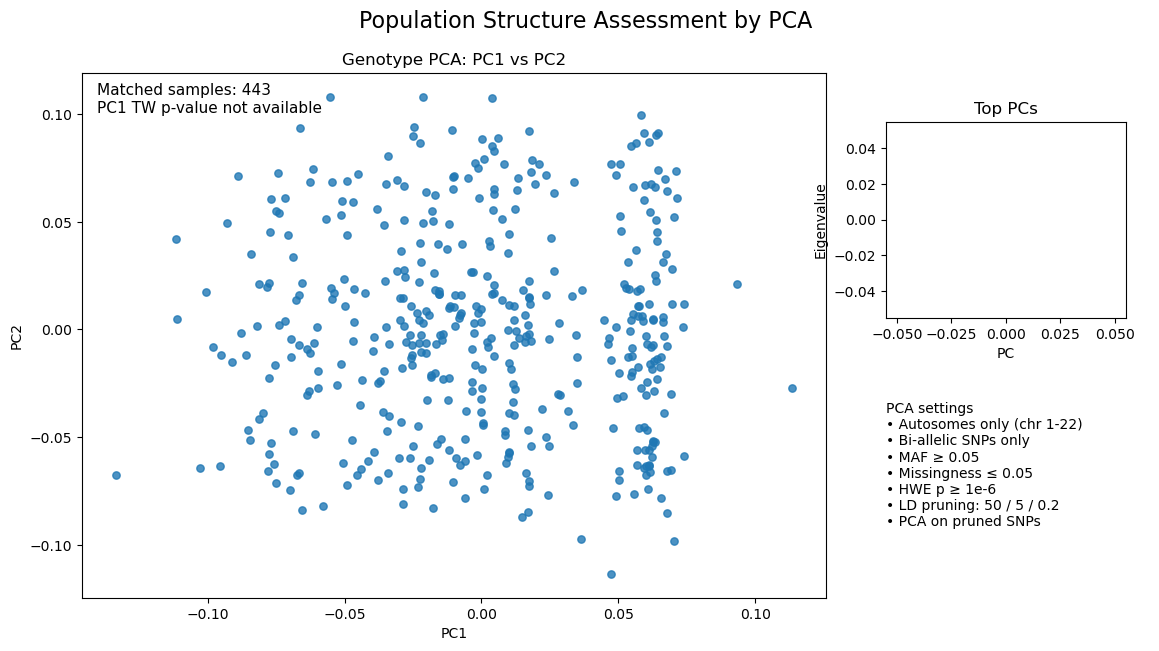

saved: /data/work/CIMA_multiomics_regulation/data/results/pca_report_figures/pca_pc1_pc2_with_scree.png


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# paths
# =========================
PROJECT_ROOT = Path("/data/work/CIMA_multiomics_regulation")
GENO_DIR = PROJECT_ROOT / "data/processed/genotype"
OUT_DIR = PROJECT_ROOT / "data/results/pca_report_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

EIGENVEC_FILE = GENO_DIR / "CIMA_pca.eigenvec"
EIGENVAL_FILE = GENO_DIR / "CIMA_pca.eigenval"
TW_FILE = GENO_DIR / "CIMA_pca.twstats.txt"

OUT_PNG = OUT_DIR / "pca_pc1_pc2_with_scree.png"

for f in [EIGENVEC_FILE, EIGENVAL_FILE, TW_FILE]:
    if not f.exists():
        raise FileNotFoundError(f"missing file: {f}")

print("EIGENVEC_FILE:", EIGENVEC_FILE)
print("EIGENVAL_FILE:", EIGENVAL_FILE)
print("TW_FILE:", TW_FILE)

# =========================
# read eigenvec
# plink2 .eigenvec usually: FID IID PC1 PC2 ...
# =========================
eig = pd.read_csv(EIGENVEC_FILE, sep=r"\s+")
print("eigenvec shape:", eig.shape)
display(eig.head())

# 自动识别 PC 列
pc_cols = [c for c in eig.columns if str(c).upper().startswith("PC")]
if len(pc_cols) < 2:
    raise ValueError(f"PC columns not found in eigenvec: {eig.columns.tolist()}")

# =========================
# read twstats
# =========================
tw = pd.read_csv(TW_FILE, sep=r"\s+")
print("twstats shape:", tw.shape)
display(tw.head())

pc_col = None
eig_col = None
p_col = None

for c in tw.columns:
    cl = c.lower()
    if cl in ["#n", "n"]:
        pc_col = c
    elif "eigenvalue" in cl:
        eig_col = c
    elif "p-value" in cl or "pvalue" in cl:
        p_col = c

if pc_col is None or eig_col is None:
    raise ValueError(f"cannot identify twstats columns: {tw.columns.tolist()}")

tw_plot = tw[[pc_col, eig_col] + ([p_col] if p_col is not None else [])].copy()
tw_plot = tw_plot.rename(columns={pc_col: "PC", eig_col: "eigenvalue"})
if p_col is not None:
    tw_plot = tw_plot.rename(columns={p_col: "p_value"})
else:
    tw_plot["p_value"] = np.nan

tw_plot["PC"] = pd.to_numeric(tw_plot["PC"], errors="coerce")
tw_plot["eigenvalue"] = pd.to_numeric(tw_plot["eigenvalue"], errors="coerce")
tw_plot["p_value"] = pd.to_numeric(tw_plot["p_value"], errors="coerce")
tw_plot = tw_plot.dropna(subset=["PC", "eigenvalue"]).copy()
tw_plot["PC"] = tw_plot["PC"].astype(int)

n_samples = eig.shape[0]

pc1_p = tw_plot.loc[tw_plot["PC"] == 1, "p_value"]
if len(pc1_p) > 0 and pd.notna(pc1_p.iloc[0]):
    pc1_sig_text = f"PC1 TW p = {pc1_p.iloc[0]:.2e}"
else:
    pc1_sig_text = "PC1 TW p-value not available"

# =========================
# figure
# =========================
fig = plt.figure(figsize=(12, 7))

# main scatter
ax1 = fig.add_axes([0.08, 0.12, 0.62, 0.75])
ax1.scatter(eig[pc_cols[0]], eig[pc_cols[1]], s=28, alpha=0.8)

ax1.set_xlabel(pc_cols[0])
ax1.set_ylabel(pc_cols[1])
ax1.set_title("Genotype PCA: PC1 vs PC2")

ax1.text(
    0.02, 0.98,
    f"Matched samples: {n_samples}\n{pc1_sig_text}",
    transform=ax1.transAxes,
    ha="left",
    va="top",
    fontsize=11
)

# inset scree plot
ax2 = fig.add_axes([0.75, 0.52, 0.20, 0.28])
ax2.plot(tw_plot["PC"], tw_plot["eigenvalue"], marker="o")
ax2.set_xlabel("PC")
ax2.set_ylabel("Eigenvalue")
ax2.set_title("Top PCs")

pc1_row = tw_plot[tw_plot["PC"] == 1]
if pc1_row.shape[0] > 0:
    ax2.scatter(pc1_row["PC"], pc1_row["eigenvalue"], s=60)
    ax2.text(
        int(pc1_row["PC"].iloc[0]),
        float(pc1_row["eigenvalue"].iloc[0]),
        "  PC1",
        va="bottom",
        fontsize=10
    )

# parameter box
ax3 = fig.add_axes([0.75, 0.14, 0.22, 0.26])
ax3.axis("off")
param_text = (
    "PCA settings\n"
    "• Autosomes only (chr 1-22)\n"
    "• Bi-allelic SNPs only\n"
    "• MAF ≥ 0.05\n"
    "• Missingness ≤ 0.05\n"
    "• HWE p ≥ 1e-6\n"
    "• LD pruning: 50 / 5 / 0.2\n"
    "• PCA on pruned SNPs"
)
ax3.text(0.0, 1.0, param_text, ha="left", va="top", fontsize=10)

fig.suptitle("Population Structure Assessment by PCA", fontsize=16, y=0.96)

plt.savefig(OUT_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("saved:", OUT_PNG)

shape: (443, 14)
columns: ['FID', 'IID', 'age', 'SEX', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10']

SEX value counts:
SEX
1    246
2    197
Name: count, dtype: int64


,FID,IID,age,SEX,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
0,E-B21106356138,E-B21106356138,23,1,-0.073847,0.002028,-0.012433,-0.037921,-0.014996,-0.027292,-0.013141,-0.067857,0.064526,0.022914
1,E-B21133356716,E-B21133356716,59,2,-0.049211,0.043807,-0.024668,0.087450,-0.025979,-0.042605,0.012079,-0.027078,-0.015667,0.014470
2,E-B21138997257,E-B21138997257,68,2,0.060666,-0.074132,-0.060308,-0.005670,-0.119269,0.077326,-0.065876,-0.038970,0.021952,0.041801
3,E-B21155258684,E-B21155258684,35,1,-0.066137,0.093654,0.020911,0.136489,-0.021529,-0.024835,-0.007441,0.005394,-0.059743,0.006065
4,E-B21296798284,E-B21296798284,29,1,0.004673,0.082869,0.000120,-0.046812,0.074060,-0.029975,-0.007135,0.038979,-0.009588,-0.099521


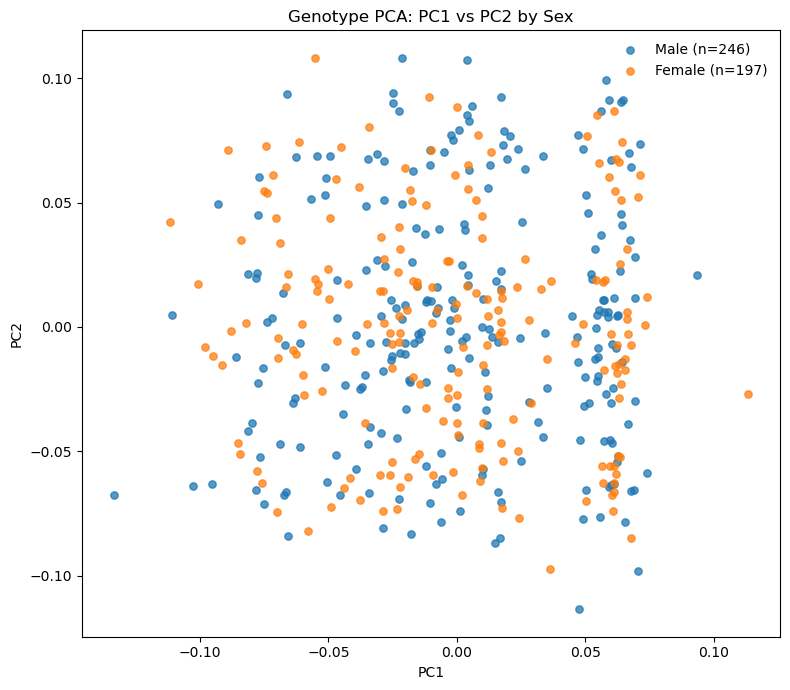

saved: /data/work/CIMA_multiomics_regulation/data/results/pca_report_figures/pca_pc1_pc2_by_sex.png


/tmp/ipykernel_2132/2792681788.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([male, female], labels=["Male", "Female"])
/tmp/ipykernel_2132/2792681788.py:65: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([male, female], labels=["Male", "Female"])


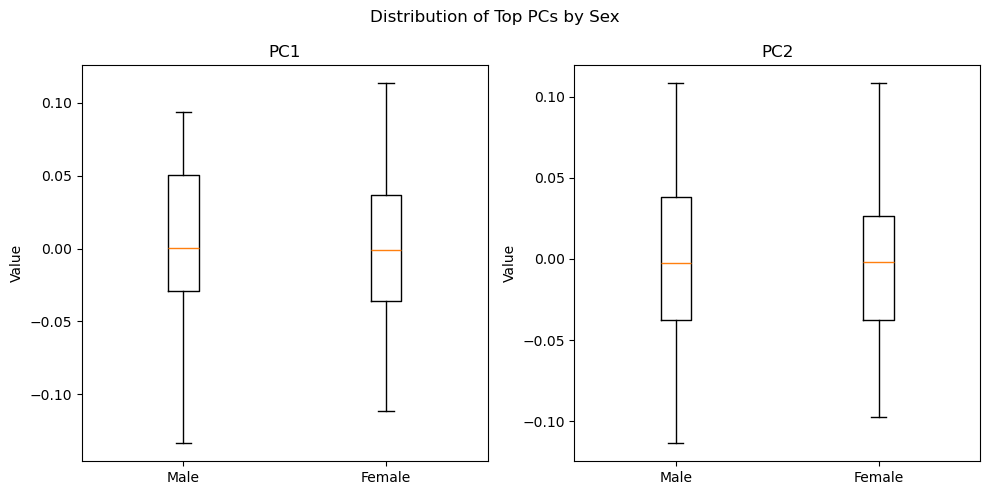

saved: /data/work/CIMA_multiomics_regulation/data/results/pca_report_figures/pca_top2_boxplot_by_sex.png


ModuleNotFoundError: No module named 'scipy'

In [5]:
from pathlib import Path
import pandas as pd

COVAR_FILE = Path("/data/work/CIMA_multiomics_regulation/data/processed/meta/CIMA_plink_covariates.tsv")
OUT_DIR = Path("/data/work/CIMA_multiomics_regulation/data/results/pca_report_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(COVAR_FILE, sep="\t")

print("shape:", df.shape)
print("columns:", df.columns.tolist())
print()
print("SEX value counts:")
print(df["SEX"].value_counts(dropna=False).sort_index())

display(df.head())
import matplotlib.pyplot as plt

plot_df = df.copy()

sex_map = {
    1: "Male",
    2: "Female",
    "1": "Male",
    "2": "Female",
    0: "Female",
    "0": "Female",
}
plot_df["SEX_LABEL"] = plot_df["SEX"].map(sex_map).fillna("Unknown")

male_n = (plot_df["SEX_LABEL"] == "Male").sum()
female_n = (plot_df["SEX_LABEL"] == "Female").sum()

plt.figure(figsize=(8, 7))

for label in ["Male", "Female", "Unknown"]:
    sub = plot_df[plot_df["SEX_LABEL"] == label]
    if sub.shape[0] == 0:
        continue
    plt.scatter(sub["PC1"], sub["PC2"], s=28, alpha=0.75, label=f"{label} (n={sub.shape[0]})")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Genotype PCA: PC1 vs PC2 by Sex")
plt.legend(frameon=False)
plt.tight_layout()

out_png = OUT_DIR / "pca_pc1_pc2_by_sex.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("saved:", out_png)
import matplotlib.pyplot as plt

plot_df = df.copy()
plot_df["SEX_LABEL"] = plot_df["SEX"].map(sex_map).fillna("Unknown")
plot_df = plot_df[plot_df["SEX_LABEL"].isin(["Male", "Female"])].copy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, pc in zip(axes, ["PC1", "PC2"]):
    male = plot_df.loc[plot_df["SEX_LABEL"] == "Male", pc].dropna()
    female = plot_df.loc[plot_df["SEX_LABEL"] == "Female", pc].dropna()

    ax.boxplot([male, female], labels=["Male", "Female"])
    ax.set_title(pc)
    ax.set_ylabel("Value")

plt.suptitle("Distribution of Top PCs by Sex")
plt.tight_layout()

out_png = OUT_DIR / "pca_top2_boxplot_by_sex.png"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()

print("saved:", out_png)
import numpy as np
import pandas as pd
from scipy import stats

test_df = df.copy()
test_df["SEX_LABEL"] = test_df["SEX"].map(sex_map).fillna("Unknown")
test_df = test_df[test_df["SEX_LABEL"].isin(["Male", "Female"])].copy()

pc_cols = [f"PC{i}" for i in range(1, 11)]

rows = []
for pc in pc_cols:
    male = pd.to_numeric(test_df.loc[test_df["SEX_LABEL"] == "Male", pc], errors="coerce").dropna()
    female = pd.to_numeric(test_df.loc[test_df["SEX_LABEL"] == "Female", pc], errors="coerce").dropna()

    t_stat, p_val = stats.ttest_ind(male, female, equal_var=False)

    rows.append({
        "PC": pc,
        "male_n": len(male),
        "female_n": len(female),
        "male_mean": male.mean(),
        "female_mean": female.mean(),
        "mean_diff_male_minus_female": male.mean() - female.mean(),
        "t_stat": t_stat,
        "p_value": p_val,
    })

res = pd.DataFrame(rows).sort_values("p_value").reset_index(drop=True)
display(res)

out_tsv = OUT_DIR / "pca_sex_difference_welch_ttest.tsv"
res.to_csv(out_tsv, sep="\t", index=False)
print("saved:", out_tsv)
import statsmodels.api as sm
import pandas as pd

lm_df = df.copy()
lm_df["SEX_NUM"] = pd.to_numeric(lm_df["SEX"], errors="coerce")
lm_df["age"] = pd.to_numeric(lm_df["age"], errors="coerce")

# 这里默认 1=Male, 2=Female
# 为了更直观，转成 Female=1, Male=0
lm_df["SEX_FEMALE"] = (lm_df["SEX_NUM"] == 2).astype(int)

pc_cols = [f"PC{i}" for i in range(1, 11)]

rows = []
for pc in pc_cols:
    tmp = lm_df[["SEX_FEMALE", "age", pc]].copy()
    tmp[pc] = pd.to_numeric(tmp[pc], errors="coerce")
    tmp = tmp.dropna()

    X = sm.add_constant(tmp[["SEX_FEMALE", "age"]])
    y = tmp[pc]

    model = sm.OLS(y, X).fit()

    rows.append({
        "PC": pc,
        "n": tmp.shape[0],
        "beta_sex_female": model.params.get("SEX_FEMALE", np.nan),
        "p_sex_female": model.pvalues.get("SEX_FEMALE", np.nan),
        "beta_age": model.params.get("age", np.nan),
        "p_age": model.pvalues.get("age", np.nan),
        "r_squared": model.rsquared,
    })

lm_res = pd.DataFrame(rows).sort_values("p_sex_female").reset_index(drop=True)
display(lm_res)

out_tsv = OUT_DIR / "pca_sex_age_linear_model.tsv"
lm_res.to_csv(out_tsv, sep="\t", index=False)
print("saved:", out_tsv)